ESCALAMIENTO

In [169]:
import pandas as pd
import numpy as np

In [170]:
data = pd.read_csv('/Users/alevaldivia/Downloads/Lab_3/Salarios_minimos.csv')

In [171]:
data.describe()


,Periodo,Salario
count,34.000000,34.000000
mean,2002.177353,39.560588
std,9.117739,23.233915
min,1988.250000,8.000000
25%,1995.075000,16.830000
50%,2001.500000,41.250000
75%,2009.750000,56.795000
max,2018.000000,88.360000


In [172]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [173]:
lr = LinearRegression()
x=data[['Periodo']]
y=data['Salario']
lr.fit(x,y)
print(lr.intercept_)
print(lr.coef_)

-5022.60217164143
[2.52832885]


In [174]:
pred=lr.predict(x)

In [175]:
# Errores del modelo
error = y - pred

# RSS = suma de los errores al cuadrado
RSS = np.sum(error**2)

# Numero de datos
n = len(y)

# p = numero de parametros del modelo
# beta 0 y beta 1
p = 2

# Varianza del error
sigma2 = RSS / (n - p)

# Promedio de x
x_prom = data['Periodo'].mean()

# Suma de (xi - x_prom)^2
suma_x = np.sum((data['Periodo'] - x_prom)**2)

# Error estandar de beta 1 al cuadrado
SE_B1_2 = sigma2 / suma_x

# Error estandar de beta 1
SE_B1 = np.sqrt(SE_B1_2)

# Error estandar de beta 0 al cuadrado
SE_B0_2 = sigma2 * ((1/n) + (x_prom**2 / suma_x))

# Error estandar de beta 0
SE_B0 = np.sqrt(SE_B0_2)

print('RSS:', RSS)
print('Promedio de x:', x_prom)
print('Suma de (xi - x_prom)^2:', suma_x)
print('Varianza del error:', sigma2)
print('Error beta 1:', SE_B1)
print('Error beta 0:', SE_B0)

RSS: 276.887220869309
Promedio de x: 2002.1773529411764
Suma de (xi - x_prom)^2: 2743.3942617647112
Varianza del error: 8.652725652165906
Error beta 1: 0.056160679532908944
Error beta 0: 112.44477232305225


In [176]:
Periodo = data['Periodo']-1988
Periodo

0      0.25
1      1.00
2      1.50
3      2.00
4      2.84
5      3.84
6      5.00
7      6.00
8      7.00
9      7.30
10     8.00
11     8.30
12     9.00
13    10.00
14    11.00
15    12.00
16    13.00
17    14.00
18    15.00
19    16.00
20    17.00
21    18.00
22    19.00
23    20.00
24    21.00
25    22.00
26    23.00
27    24.00
28    25.00
29    26.00
30    27.00
31    28.00
32    29.00
33    30.00
Name: Periodo, dtype: float64

In [177]:
lr = LinearRegression()
x=Periodo.values.reshape(-1,1)
y=data['Salario']
lr.fit(x,y)
print(lr.intercept_)
print(lr.coef_)

3.715577808507625
[2.52832885]


In [178]:
import matplotlib.pyplot as plt

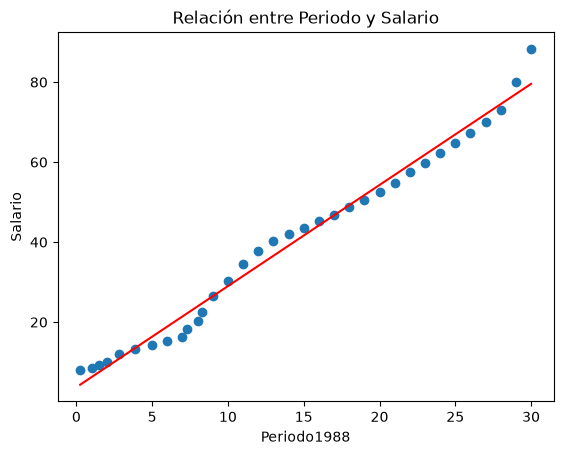

In [179]:
plt.scatter(Periodo, data['Salario'])
plt.plot(Periodo, pred, color='red') 
plt.xlabel('Periodo' + str(1988))
plt.ylabel('Salario')
plt.title('Relación entre Periodo y Salario')
plt.show()

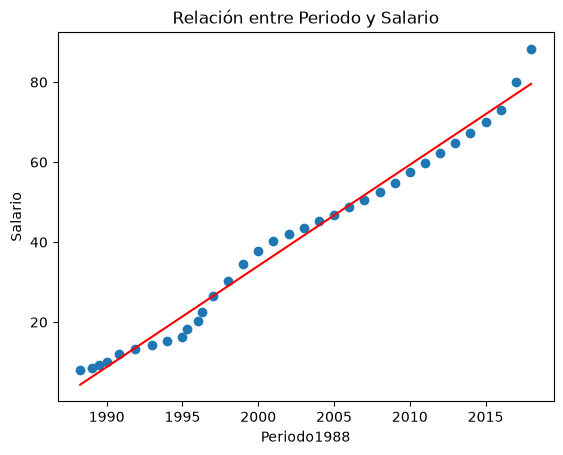

In [180]:
plt.scatter(data['Periodo'], data['Salario'])
plt.plot(data['Periodo'], pred, color='red') 
plt.xlabel('Periodo' + str(1988))
plt.ylabel('Salario')
plt.title('Relación entre Periodo y Salario')
plt.show()

In [181]:
data2 = pd.read_csv('/Users/alevaldivia/Downloads/Lab_3/bateria_tableta.txt')

In [182]:
data2.describe()

,carga,duracion
count,100.000000,100.000000
mean,4.573000,6.206800
std,2.788603,2.454116
min,0.000000,0.000000
25%,1.987500,3.975000
50%,4.375000,8.000000
75%,6.522500,8.000000
max,11.720000,8.000000


In [183]:
data2['carga_nueva'] = 1 + data2['carga']/11.72

In [184]:
# Variable x con el nuevo dominio [1,2]
x = np.reshape(data2['carga_nueva'],(-1,1))

# Potencias hasta grado 9
x2 = x**2
x3 = x**3
x4 = x**4
x5 = x**5
x6 = x**6
x7 = x**7
x8 = x**8
x9 = x**9

# Matriz con todas las variables
X9 = np.hstack([x,x2,x3,x4,x5,x6,x7,x8,x9])

# Regresion de grado 9
lr9 = LinearRegression()

lr9.fit(X9,data2['duracion'])

# Resultados
print('Intercepto:',lr9.intercept_)
print('Coeficientes:',lr9.coef_)

Intercepto: 25.339432620948244
Coeficientes: [-38.7778695  -27.49035908   9.98557454  39.02008643  28.38556741
 -21.14924722 -46.4044648   39.11470934  -8.12990227]


In [185]:
lr9.score(X9,data2['duracion'])

0.9924685766553696

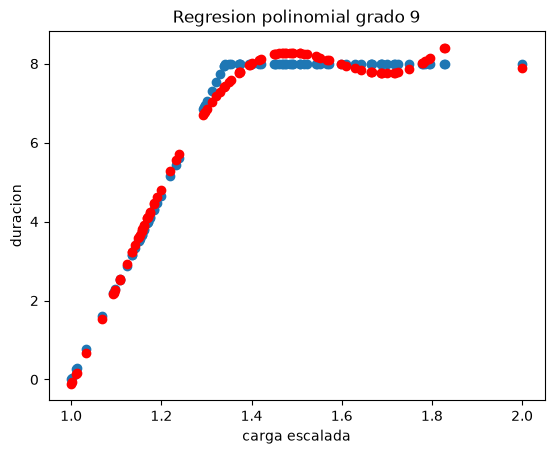

In [186]:
# Datos originales
plt.scatter(x, data2['duracion'])

# Prediccion del modelo grado 9
pred9 = lr9.predict(X9)

# Modelo
plt.scatter(x, pred9, color='red')

plt.xlabel('carga escalada')
plt.ylabel('duracion')
plt.title('Regresion polinomial grado 9')
plt.show()

In [187]:
data['Periodo_nuevo'] = 1 + Periodo/30

In [188]:
# Variable x con el nuevo dominio [1,2]
x = np.reshape(data['Periodo_nuevo'],(-1,1))

# Potencias hasta grado 9
x2 = x**2
x3 = x**3
x4 = x**4
x5 = x**5
x6 = x**6
x7 = x**7
x8 = x**8
x9 = x**9

# Matriz con todas las variables
X9 = np.hstack([x,x2,x3,x4,x5,x6,x7,x8,x9])

# Regresion de grado 9
lr9s = LinearRegression()

lr9s.fit(X9,data['Salario'])

# Resultados
print('Intercepto:',lr9s.intercept_)
print('Coeficientes:',lr9s.coef_)
lr9s.score(X9,data['Salario'])

Intercepto: 255.07504301405922
Coeficientes: [-221.55721573 -197.47375796  -17.34230792  161.33448864  167.86070456
  -43.37581339 -208.84368938  138.29123057  -24.6948203 ]


0.9961520245951032

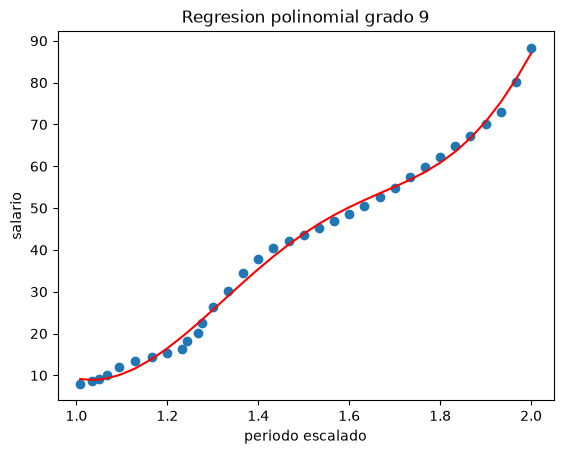

In [189]:
# Datos originales
plt.scatter(x, data['Salario'])

# Prediccion del modelo grado 9
pred9s = lr9s.predict(X9)

# Modelo
plt.plot(x, pred9s, color='red')

plt.xlabel('periodo escalado')
plt.ylabel('salario')
plt.title('Regresion polinomial grado 9')
plt.show()

In [190]:
# Promedio y desviacion de carga
media = data2['carga'].mean()
desv = data2['carga'].std()

# Estandarizacion
data2['carga_est'] = (data2['carga'] - media) / desv

# Comprobar
print(data2['carga_est'].mean())
print(data2['carga_est'].std())

-1.3988810110276973e-16
1.0


In [191]:
# Variable x estandarizada
x = np.reshape(data2['carga_est'],(-1,1))

# Potencias hasta grado 9
x2 = x**2
x3 = x**3
x4 = x**4
x5 = x**5
x6 = x**6
x7 = x**7
x8 = x**8
x9 = x**9

# Matriz
X9 = np.hstack([x,x2,x3,x4,x5,x6,x7,x8,x9])

# Regresion grado 9
lr9_est = LinearRegression()

lr9_est.fit(X9,data2['duracion'])

print('Intercepto:',lr9_est.intercept_)
print('Coeficientes:',lr9_est.coef_)
print('R2:',lr9_est.score(X9,data2['duracion']))

Intercepto: 8.078921730458692
Coeficientes: [ 0.87305015 -3.8335034   2.66564513  2.1427503  -1.77019112 -0.71117705
  0.50914141  0.08629359 -0.05190043]
R2: 0.99891267294693


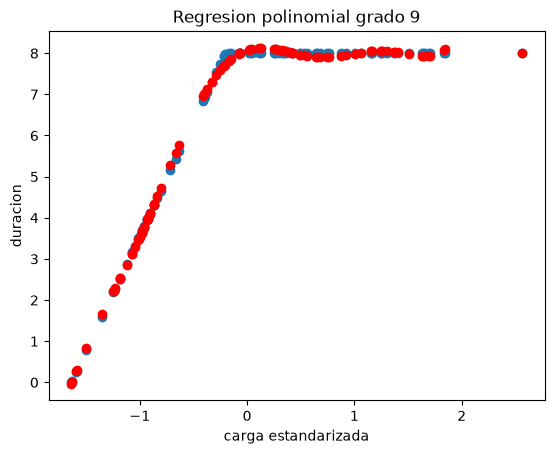

In [192]:
pred9 = lr9_est.predict(X9)

plt.scatter(x,data2['duracion'])
plt.scatter(x,pred9,color='red')

plt.xlabel('carga estandarizada')
plt.ylabel('duracion')
plt.title('Regresion polinomial grado 9')
plt.show()

In [193]:
# Promedio y desviacion del periodo
media = data['Periodo'].mean()
desv = data['Periodo'].std()

# Estandarizacion
data['Periodo_est'] = (data['Periodo'] - media) / desv

# Comprobar
print(data['Periodo_est'].mean())
print(data['Periodo_est'].std())

4.3951770327807665e-15
0.9999999999999998


In [194]:
# Variable x estandarizada
x = np.reshape(data['Periodo_est'],(-1,1))

# Potencias hasta grado 9
x2 = x**2
x3 = x**3
x4 = x**4
x5 = x**5
x6 = x**6
x7 = x**7
x8 = x**8
x9 = x**9

# Matriz
X9 = np.hstack([x,x2,x3,x4,x5,x6,x7,x8,x9])

# Regresion grado 9
lr9s_est = LinearRegression()

lr9s_est.fit(X9,data['Salario'])

print('Intercepto:',lr9s_est.intercept_)
print('Coeficientes:',lr9s_est.coef_)
print('R2:',lr9s_est.score(X9,data['Salario']))

Intercepto: 43.075910823587066
Coeficientes: [ 15.82253252 -24.5283758   30.75038826  32.26935306 -36.9013272
 -16.31923565  16.46063258   2.93008738  -2.49742081]
R2: 0.9994664256490208


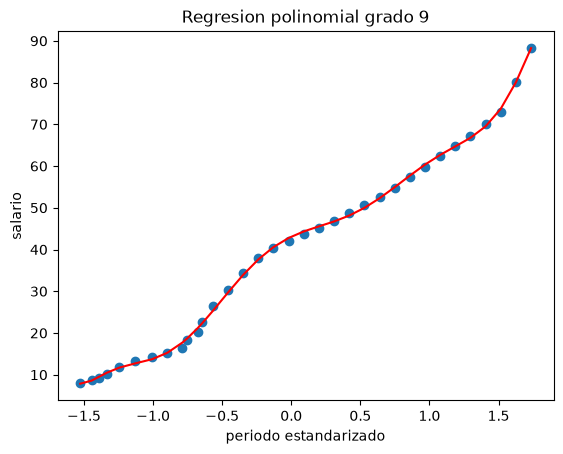

In [195]:
pred9s = lr9s_est.predict(X9)

plt.scatter(x,data['Salario'])
plt.plot(x,pred9s,color='red')

plt.xlabel('periodo estandarizado')
plt.ylabel('salario')
plt.title('Regresion polinomial grado 9')
plt.show()

In [196]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [197]:
scaler = StandardScaler()
scaler.fit(data[['Periodo']])
x_scaler = scaler.fit_transform(data[['Periodo']])

In [198]:
print(x_scaler.mean())
print(x_scaler.std())

4.486607164220486e-15
0.9999999999999999


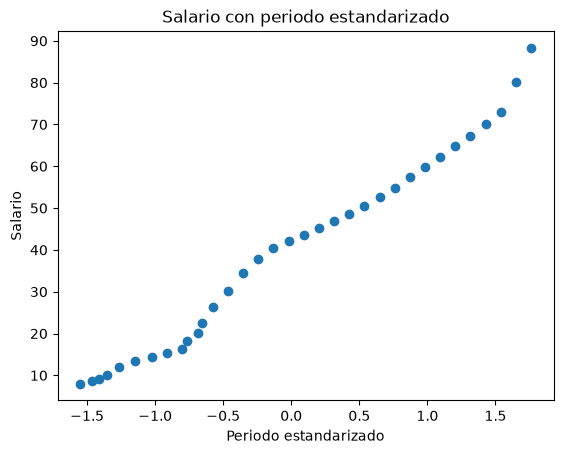

In [199]:
plt.scatter(x_scaler, data['Salario'])

plt.xlabel('Periodo estandarizado')
plt.ylabel('Salario')
plt.title('Salario con periodo estandarizado')
plt.show()

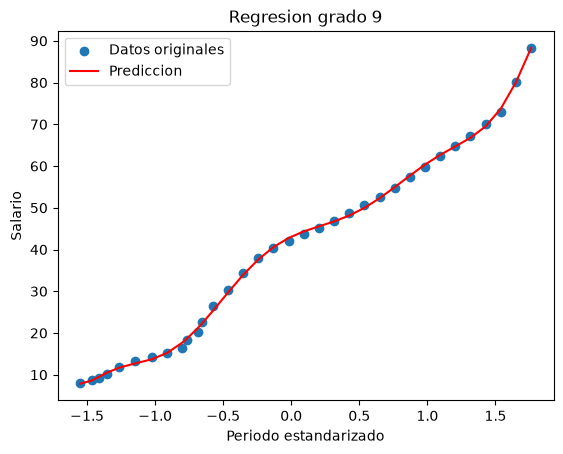

In [200]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Estandarizar Periodo
scaler = StandardScaler()
x_scaler = scaler.fit_transform(data[['Periodo']])

# Crear polinomio grado 9
poly = PolynomialFeatures(degree=9, include_bias=False)
X9 = poly.fit_transform(x_scaler)

# Regresion
lr9 = LinearRegression()
lr9.fit(X9, data['Salario'])

# Prediccion
pred = lr9.predict(X9)

# Grafica
plt.scatter(x_scaler, data['Salario'], label='Datos originales')
plt.plot(x_scaler, pred, color='red', label='Prediccion')

plt.xlabel('Periodo estandarizado')
plt.ylabel('Salario')
plt.title('Regresion grado 9')
plt.legend()
plt.show()